# 4 · The white-box arm, and the error I found in it

**CPU-only, runs from committed JSON. The raw attention tensors are not needed.**

*Thought Anchors* presents black-box/white-box agreement as mutual corroboration:
resampling importance and attention-based "receiver heads" are reported to
converge. If the white-box side is largely reading position, that agreement is
weaker evidence than it looks.

So I reimplemented it — 48 layers × 40 heads — and got **the largest effect in the
study**. Then I plotted the attention matrix instead of trusting the number.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "code"))
DATA = ROOT / "data"
TAG  = "DeepSeek-R1-Distill-Qwen-14B"

internals = json.loads((DATA / f"internals_{TAG}.json").read_text())
sweep     = json.loads((DATA / f"mingap_sweep_{TAG}.json").read_text())
print(f"{internals['layers']} layers x {internals['heads']} heads, "
      f"{internals['n_traces']} traces")

48 layers x 40 heads, 8 traces


## 4.1 The raw result

In [2]:
wb = internals["whitebox_position_only"]
print("Position-only control on the WHITE-BOX (attention) measure:")
print(f"  rho        = {wb['spearman_oos']:+.3f}  (p = {wb['spearman_p']:.2g})")
print(f"  R2_oos     = {wb['r2_oos']:+.3f}")
print(f"  top-3      = {wb['topk_agreement']['3']:.3f}  "
      f"vs chance {wb['topk_chance']['3']:.3f}  "
      f"({wb['topk_agreement']['3']/wb['topk_chance']['3']:.0f}x)")

summary = json.loads((DATA / f"summary_{TAG}.json").read_text())["kl_resampling"]
print("\nSame control on the BLACK-BOX measure, for comparison:")
print(f"  rho        = {summary['spearman_oos']:+.3f}")
print(f"  top-3      = {summary['topk_agreement']['3']:.3f}  "
      f"vs chance {summary['topk_chance']['3']:.3f}")
print("\nThe two measures come apart sharply under the same control.")

Position-only control on the WHITE-BOX (attention) measure:
  rho        = +0.574  (p = 7.2e-93)
  R2_oos     = +0.382
  top-3      = 0.375  vs chance 0.032  (12x)

Same control on the BLACK-BOX measure, for comparison:
  rho        = +0.044
  top-3      = 0.083  vs chance 0.095

The two measures come apart sharply under the same control.


## 4.2 Which heads got picked

Highest receiver score = the head whose backward attention concentrates most
sharply on a few earlier sentences.

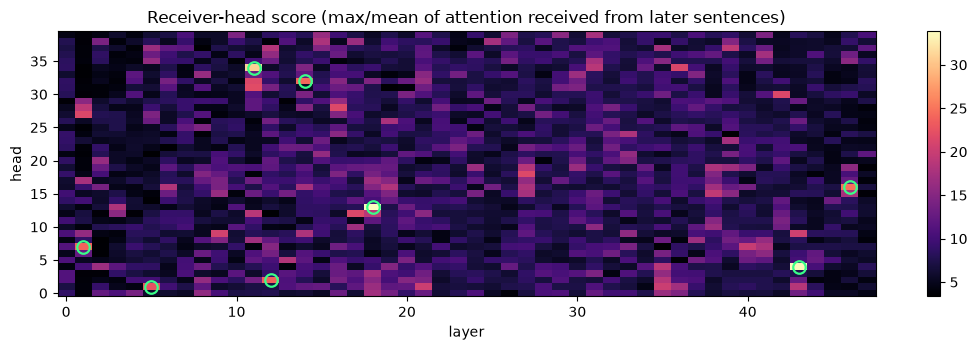

Top receiver heads:
  L18H13   peakedness 33.85
  L43H 4   peakedness 33.51
  L11H34   peakedness 31.01
  L46H16   peakedness 24.89
  L14H32   peakedness 24.13
  L 1H 7   peakedness 23.89


In [3]:
peaked = np.array(internals["peakedness_by_layer_head"])
fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.imshow(peaked.T, aspect="auto", cmap="magma", origin="lower")
for e in internals["top_receiver_heads"][:8]:
    ax.plot(e["layer"], e["head"], "o", mfc="none", mec="#39FF88", mew=1.6, ms=9)
ax.set_xlabel("layer"); ax.set_ylabel("head")
ax.set_title("Receiver-head score (max/mean of attention received from later sentences)")
fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

print("Top receiver heads:")
for e in internals["top_receiver_heads"][:6]:
    print(f"  L{e['layer']:2d}H{e['head']:2d}   peakedness {e['peakedness']:.2f}")

## 4.3 The correction

Look at `figures/fig7_attnmatrix_*.png` — the panel for these "receiver" heads is
**almost purely diagonal**. They attend to the *immediately preceding* sentence.

My receiver score used `min_gap = 1`, which counts the immediately preceding
sentence as "attention received from later" — so it selected **recency heads by
construction**. Excluding a band around the diagonal:

 min gap      rho    R2_oos   top-3   near-diagonal share
       1   +0.574    +0.382    0.38                  0.84
       2   +0.434    +0.189    0.21                  0.81
       4   +0.217    +0.045    0.00                  0.71
       8   +0.075    +0.023    0.04                  0.66
      16   +0.312    +0.094    0.50                  0.51


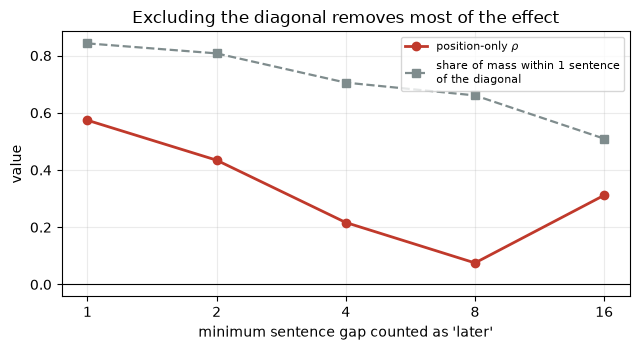

In [4]:
print(f"{'min gap':>8} {'rho':>8} {'R2_oos':>9} {'top-3':>7} {'near-diagonal share':>21}")
for g in sorted(sweep, key=int):
    v = sweep[g]
    print(f"{g:>8} {v['spearman_oos']:+8.3f} {v['r2_oos']:+9.3f} "
          f"{v['topk_agreement']['3']:7.2f} {v['near_diagonal_share']:21.2f}")

gaps = sorted(sweep, key=int)
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot([int(g) for g in gaps], [sweep[g]["spearman_oos"] for g in gaps],
        "o-", color="#C0392B", lw=2, label=r"position-only $\rho$")
ax.plot([int(g) for g in gaps], [sweep[g]["near_diagonal_share"] for g in gaps],
        "s--", color="#7f8c8d", lw=1.6, label="share of mass within 1 sentence\nof the diagonal")
ax.set_xscale("log", base=2); ax.set_xticks([int(g) for g in gaps], gaps)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("minimum sentence gap counted as 'later'"); ax.set_ylabel("value")
ax.set_title("Excluding the diagonal removes most of the effect")
ax.legend(fontsize=8); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()

**At gap 1, 84% of those heads' attention mass lies within one sentence of
the diagonal.** Requiring genuinely long-range attention collapses ρ from +0.574
to +0.075.

### What I can and cannot claim

**Can:** attention-based sentence importance, as operationalised here, is
**dominated by recency** — not the long-range broadcasting the receiver-head
account describes. The apparent black-box/white-box convergence deserves more
scrutiny than it has had.

**Cannot:** anything confident about long range. The effect returns
non-monotonically at gap 16 (ρ = +0.312, top-3 0.50). At n = 8 traces I can't
separate real structure from noise, and I don't claim to.

**This is the error in the whole project I'd most want a reader to check** — and
it was caught by plotting a matrix rather than reading a summary statistic.

## 4.4 Regenerating from raw attention

The per-trace tensors (`data/attn_*.npy`, `[layers, heads, sentences, sentences]`)
are excluded from the repo — 591 MB, two files over GitHub's 100 MB limit. To
rebuild them (needs a GPU, one forward pass per trace, no sampling):

```bash
python code/11_internals.py --model deepseek-ai/DeepSeek-R1-Distill-Qwen-14B --max-traces 8
python code/14_mingap_sweep.py --model deepseek-ai/DeepSeek-R1-Distill-Qwen-14B
```

Everything in *this* notebook runs without them.